In [315]:
# ===============================
# Module 1 : Import Libraries
# ===============================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Feature Selection
from sklearn.feature_selection import SelectKBest, chi2

# Feature Extraction
from sklearn.decomposition import PCA

# Train-Test Split
from sklearn.model_selection import train_test_split, cross_val_score

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [316]:
# Load Dataset

#df = pd.read_csv("sdcd.csv")
df = pd.read_csv("../datasets/sdcd.csv")
# Display first 5 rows
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [317]:
# Dataset Shape

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 400
Number of Columns : 26


In [318]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    
 9   ba              396 non-null    str    
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    str    
 17  wc              295 non-null    str    
 18  r

In [319]:
# Column Names

print(df.columns)

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='str')


In [320]:
# Missing Values

missing = df.isnull().sum()

print(missing)

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


In [321]:
# Duplicate Records

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [322]:
# Statistical Summary

df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [323]:
# Data Types

print(df.dtypes)

id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                   str
pc                    str
pcc                   str
ba                    str
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                   str
wc                    str
rc                    str
htn                   str
dm                    str
cad                   str
appet                 str
pe                    str
ane                   str
classification        str
dtype: object


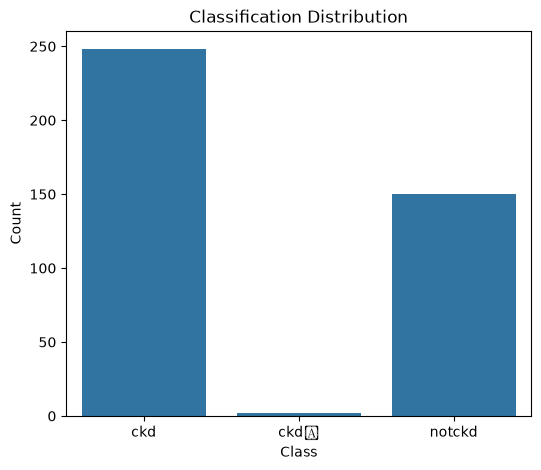

In [324]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='classification',
    data=df
)

plt.title("Classification Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

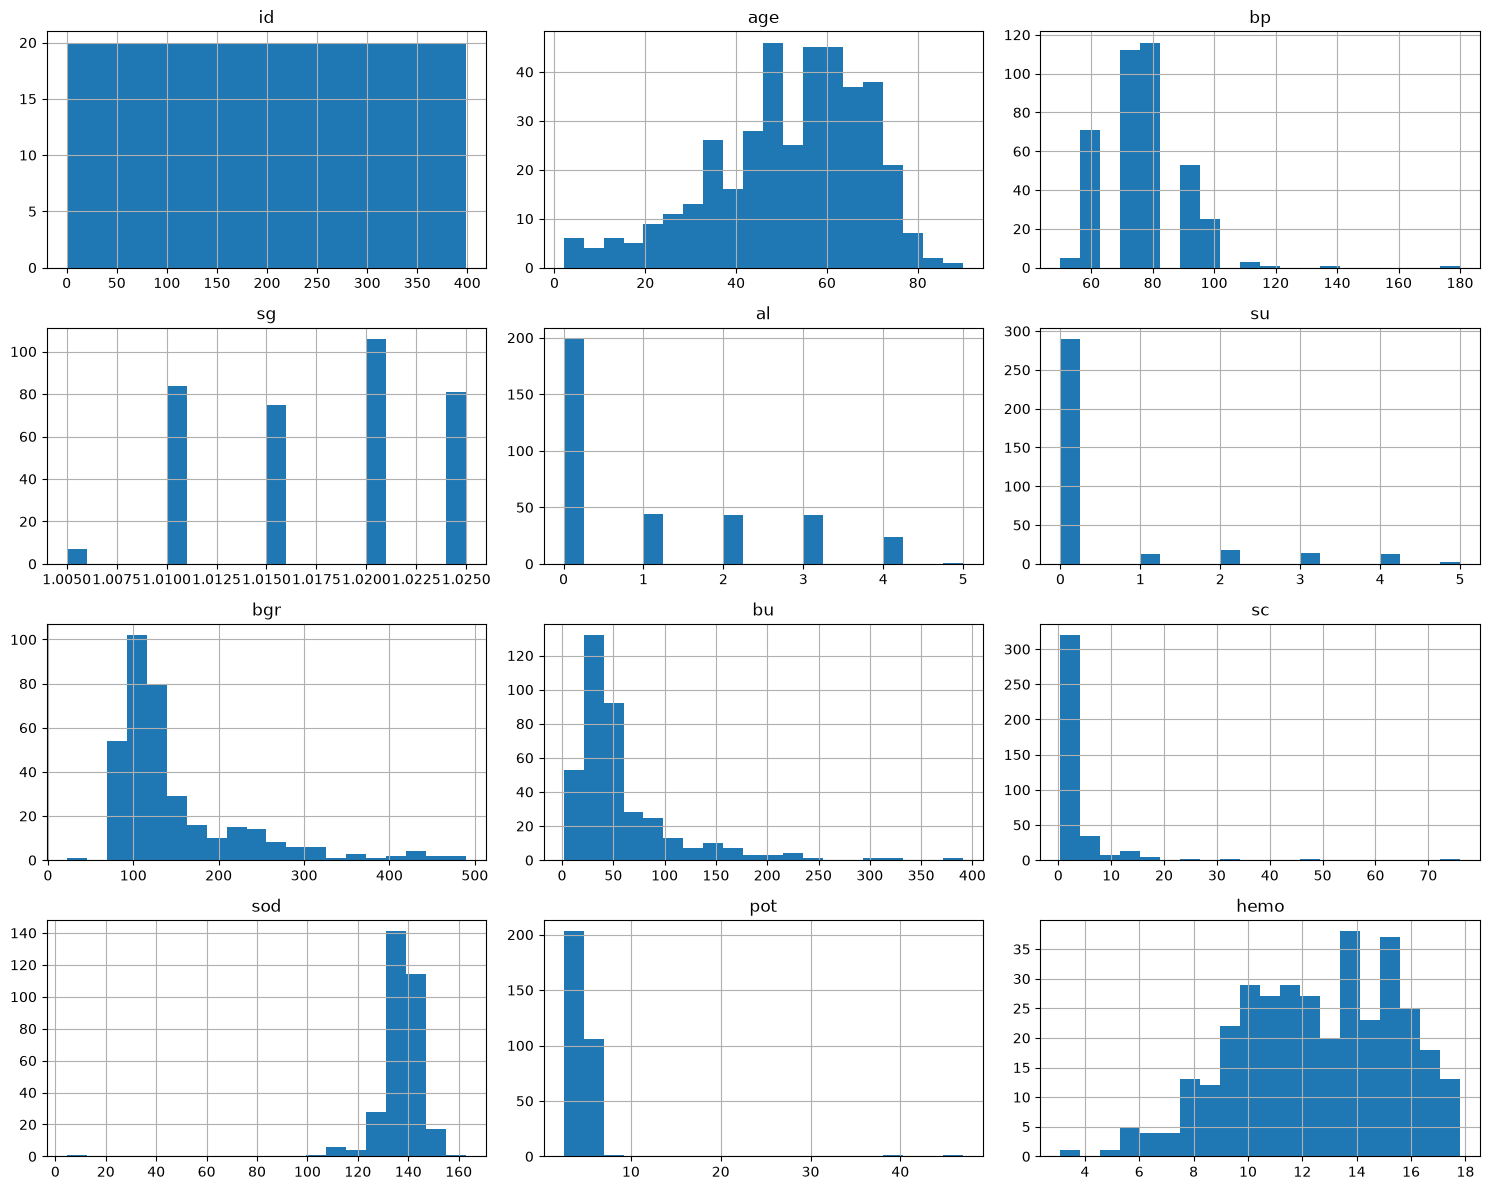

In [325]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()

plt.show()

In [326]:
# Missing Values Before Preprocessing

print("Missing Values Before Preprocessing\n")

print(df.isnull().sum())

Missing Values Before Preprocessing

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


In [327]:
# Separate Numerical and Categorical Columns

numerical_cols = df.select_dtypes(include=np.number).columns

categorical_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical Columns")

print(numerical_cols)

print("\nCategorical Columns")

print(categorical_cols)

Numerical Columns
Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot',
       'hemo'],
      dtype='str')

Categorical Columns
Index(['rbc', 'pc', 'pcc', 'ba', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='str')


In [328]:
# Handle Missing Values in Numerical Columns

num_imputer = SimpleImputer(strategy="median")

df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

In [329]:
# Handle Missing Values in Categorical Columns

cat_imputer = SimpleImputer(strategy="most_frequent")

df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [330]:
# Verify Missing Values

print("Missing Values After Imputation\n")

print(df.isnull().sum())

Missing Values After Imputation

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64


In [331]:
# Clean all categorical columns

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

print("Categorical columns cleaned successfully.")

Categorical columns cleaned successfully.


In [332]:
# Label Encoding

label_encoder = LabelEncoder()

for column in categorical_cols:
    df[column] = label_encoder.fit_transform(df[column])
    

In [333]:
    
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0.0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,...,30,69,33,1,1,0,0,0,0,0
1,1.0,7.0,50.0,1.020,4.0,0.0,1,1,0,0,...,24,53,33,0,0,0,0,0,0,0
2,2.0,62.0,80.0,1.010,2.0,3.0,1,1,0,0,...,17,67,33,0,1,0,1,0,1,0
3,3.0,48.0,70.0,1.005,4.0,0.0,1,0,1,0,...,18,59,18,1,0,0,1,1,1,0
4,4.0,51.0,80.0,1.010,2.0,0.0,1,1,0,0,...,21,65,26,0,0,0,0,0,0,0


In [334]:
# Features and Target

X = df.drop(["id", "classification"], axis=1)

y = df["classification"]

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (400, 24)
Target Shape : (400,)


In [335]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (320, 24)
Testing data : (80, 24)


In [336]:
# Feature Names

print(X.columns)

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane'],
      dtype='str')


In [337]:
# Target Classes

print(y.value_counts())

classification
0    250
1    150
Name: count, dtype: int64


In [338]:
# Correlation Matrix

corr_matrix = df.corr()

corr_matrix

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
id,1.000000,-0.186274,-0.245378,0.582504,-0.468924,-0.247181,0.231457,0.335825,-0.264142,-0.115955,...,0.557870,-0.116589,0.394271,-0.520089,-0.475106,-0.205575,-0.374394,-0.308120,-0.273096,0.838528
age,-0.186274,1.000000,0.136316,-0.160374,0.085918,0.186750,-0.014904,-0.102286,0.157401,0.042427,...,-0.204503,0.031467,-0.207539,0.395073,0.364306,0.231419,0.156581,0.094772,0.052938,-0.227842
bp,-0.245378,0.136316,1.000000,-0.166980,0.123518,0.189561,-0.150384,-0.156231,0.056808,0.110164,...,-0.276177,0.001691,-0.217852,0.266901,0.226489,0.084135,0.175054,0.056902,0.195134,-0.293693
sg,0.582504,-0.160374,-0.166980,1.000000,-0.479962,-0.292053,0.253894,0.365353,-0.306426,-0.231704,...,0.476688,0.006125,0.371304,-0.323643,-0.351016,-0.135814,-0.230975,-0.253803,-0.184155,0.659504
al,-0.468924,0.085918,0.123518,-0.479962,1.000000,0.287751,-0.394844,-0.561713,0.417868,0.377935,...,-0.437025,-0.027523,-0.381084,0.406057,0.308101,0.200957,0.303145,0.411080,0.229556,-0.531562
su,-0.247181,0.186750,0.189561,-0.292053,0.287751,1.000000,-0.092940,-0.190062,0.168091,0.119399,...,-0.175530,0.013542,-0.148619,0.254268,0.430514,0.229301,0.069216,0.116442,0.042464,-0.294555
rbc,0.231457,-0.014904,-0.150384,0.253894,-0.394844,-0.092940,1.000000,0.377394,-0.102948,-0.184402,...,0.272876,0.054374,0.164619,-0.140538,-0.145646,-0.111493,-0.160868,-0.199285,-0.107625,0.282642
pc,0.335825,-0.102286,-0.156231,0.365353,-0.561713,-0.190062,0.377394,1.000000,-0.520118,-0.330401,...,0.393486,0.077893,0.367184,-0.291719,-0.201032,-0.172295,-0.274985,-0.350227,-0.260566,0.375154
pcc,-0.264142,0.157401,0.056808,-0.306426,0.417868,0.168091,-0.102948,-0.520118,1.000000,0.275082,...,-0.260463,-0.097933,-0.239130,0.195623,0.165236,0.188029,0.189688,0.104356,0.175861,-0.265313
ba,-0.115955,0.042427,0.110164,-0.231704,0.377935,0.119399,-0.184402,-0.330401,0.275082,1.000000,...,-0.194580,-0.096370,-0.189356,0.089046,0.080070,0.162395,0.149126,0.134732,0.052208,-0.186871


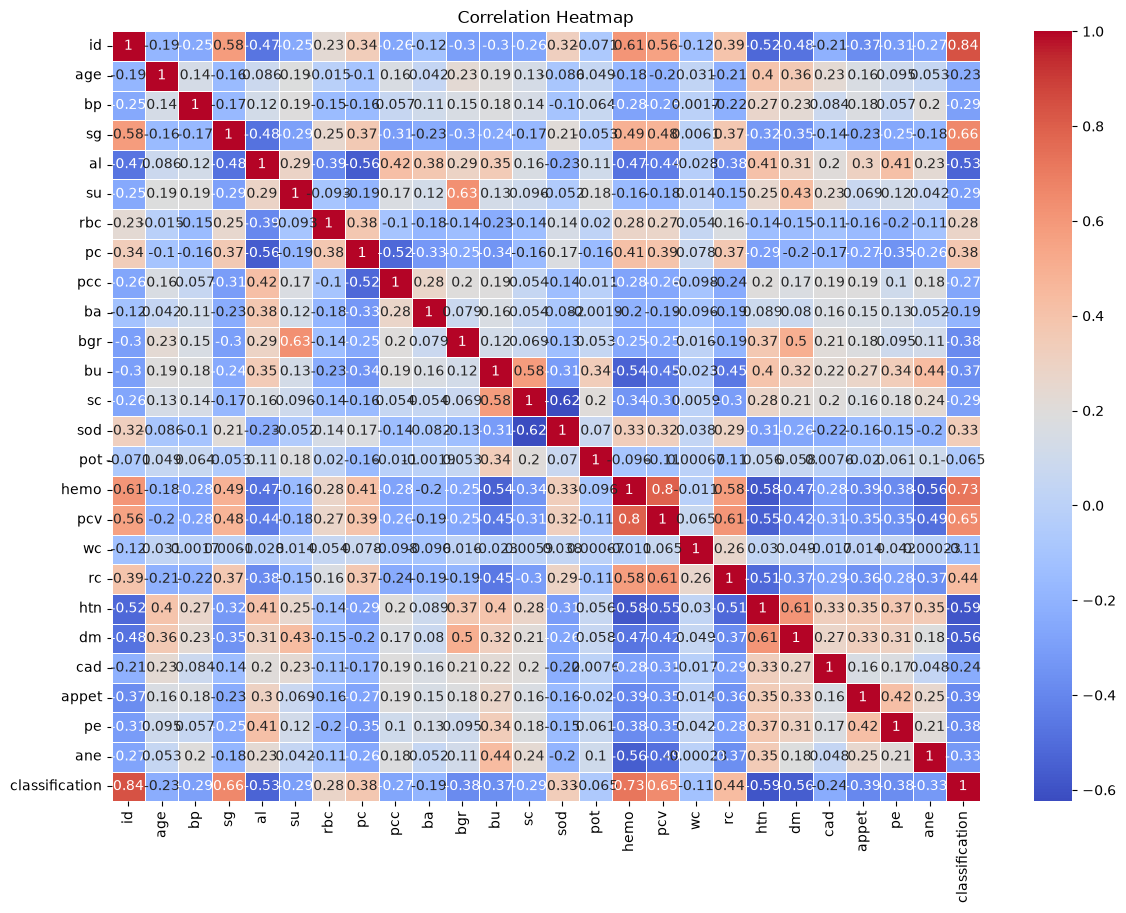

In [339]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [340]:
# Correlation with Target

corr_target = corr_matrix["classification"].sort_values(ascending=False)

print(corr_target)

classification    1.000000
id                0.838528
hemo              0.726368
sg                0.659504
pcv               0.646883
rc                0.438133
pc                0.375154
sod               0.334900
rbc               0.282642
pot              -0.065218
wc               -0.112155
ba               -0.186871
age              -0.227842
cad              -0.236088
pcc              -0.265313
sc               -0.291245
bp               -0.293693
su               -0.294555
ane              -0.325396
bu               -0.369393
pe               -0.375154
bgr              -0.379321
appet            -0.393341
al               -0.531562
dm               -0.559060
htn              -0.590438
Name: classification, dtype: float64


In [341]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

chi_selector = SelectKBest(
    score_func=chi2,
    k=10
)

X_chi = chi_selector.fit_transform(X, y)

In [342]:
scores = pd.DataFrame({

    "Feature": X.columns,

    "Chi-Square Score": chi_selector.scores_

})

scores = scores.sort_values(
    by="Chi-Square Score",
    ascending=False
)

print(scores)

   Feature  Chi-Square Score
10      bu       2343.097145
9      bgr       2241.651289
15     pcv        434.240164
11      sc        357.792101
17      rc        234.861062
3       al        216.000000
14    hemo        123.856342
0      age        115.859940
4       su         94.800000
18     htn         88.200000
19      dm         82.200000
1       bp         81.786701
16      wc         60.153746
21   appet         49.200000
22      pe         45.600000
23     ane         36.000000
12     sod         27.558749
7      pcc         25.200000
20     cad         20.400000
8       ba         13.200000
6       pc         10.696296
5      rbc          3.754674
13     pot          2.951339
2       sg          0.005035


In [343]:
selected_features = X.columns[
    chi_selector.get_support()
]

print("Selected Features\n")

print(selected_features)

Selected Features

Index(['age', 'al', 'su', 'bgr', 'bu', 'sc', 'hemo', 'pcv', 'rc', 'htn'], dtype='str')


In [344]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [345]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)

X_pca = pca.fit_transform(X_scaled)

In [346]:
print("Original Shape :", X.shape)

print("Reduced Shape :", X_pca.shape)

Original Shape : (400, 24)
Reduced Shape : (400, 10)


In [347]:
print("Explained Variance Ratio\n")

print(pca.explained_variance_ratio_)

Explained Variance Ratio

[0.282262   0.07726504 0.07340902 0.05370669 0.05122602 0.04777738
 0.04358581 0.03937797 0.03852371 0.03349654]


In [348]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (280, 10)
Testing Shape : (120, 10)


In [349]:
# Logistic Regression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [350]:
# Decision Tree

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [351]:
# KNN

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

In [352]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [353]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning for Random Forest

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Best Cross-Validation Accuracy:
0.9964285714285716


In [ ]:
# Use the tuned Random Forest model

rf_model_tuned = grid_search.best_estimator_

rf_tuned_pred = rf_model_tuned.predict(X_test)

print("Tuned Random Forest Accuracy:",
      accuracy_score(y_test, rf_tuned_pred))

print("Tuned Random Forest Precision:",
      precision_score(y_test, rf_tuned_pred, zero_division=0))

print("Tuned Random Forest Recall:",
      recall_score(y_test, rf_tuned_pred, zero_division=0))

print("Tuned Random Forest F1 Score:",
      f1_score(y_test, rf_tuned_pred, zero_division=0))

In [354]:
# Accuracy Comparison

lr_acc = accuracy_score(y_test, lr_pred)

dt_acc = accuracy_score(y_test, dt_pred)

knn_acc = accuracy_score(y_test, knn_pred)

rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy :", lr_acc)

print("Decision Tree Accuracy :", dt_acc)

print("KNN Accuracy :", knn_acc)

print("Random Forest Accuracy :", rf_acc)

Logistic Regression Accuracy : 0.9916666666666667
Decision Tree Accuracy : 0.9583333333333334
KNN Accuracy : 0.975
Random Forest Accuracy : 0.9916666666666667


In [355]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "KNN",
        "Random Forest"
    ],

    "Accuracy":[
        lr_acc,
        dt_acc,
        knn_acc,
        rf_acc
    ]

})

comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.991667
3,Random Forest,0.991667
2,KNN,0.975000
1,Decision Tree,0.958333


In [356]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print(best_model)

Model       Logistic Regression
Accuracy               0.991667
Name: 0, dtype: object


In [357]:
print("Logistic Regression")

print(classification_report(y_test, lr_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        75
           1       0.98      1.00      0.99        45

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



In [358]:
print("Decision Tree")

print(classification_report(y_test, dt_pred))

Decision Tree
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        75
           1       0.98      0.91      0.94        45

    accuracy                           0.96       120
   macro avg       0.96      0.95      0.95       120
weighted avg       0.96      0.96      0.96       120



In [359]:
print("KNN")

print(classification_report(y_test, knn_pred))

KNN
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        75
           1       0.94      1.00      0.97        45

    accuracy                           0.97       120
   macro avg       0.97      0.98      0.97       120
weighted avg       0.98      0.97      0.98       120



In [360]:
print("Random Forest")

print(classification_report(y_test, rf_pred))

Random Forest
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        75
           1       0.98      1.00      0.99        45

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



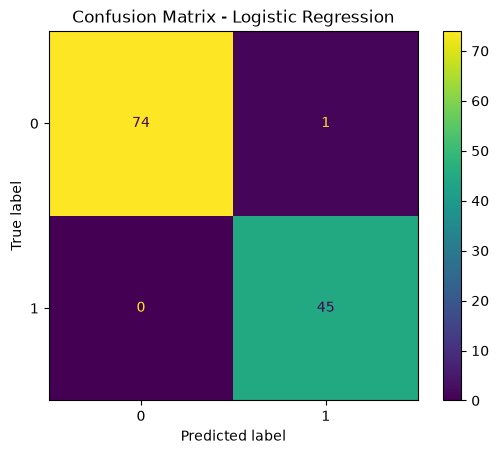

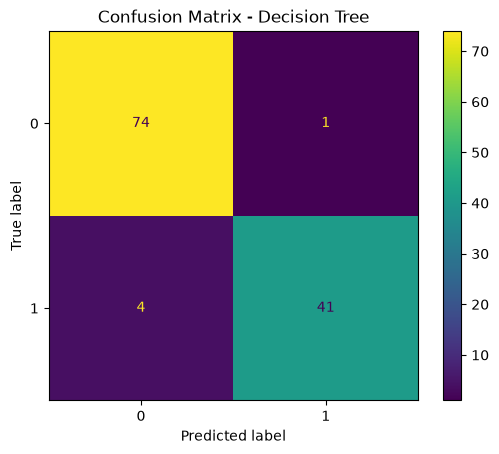

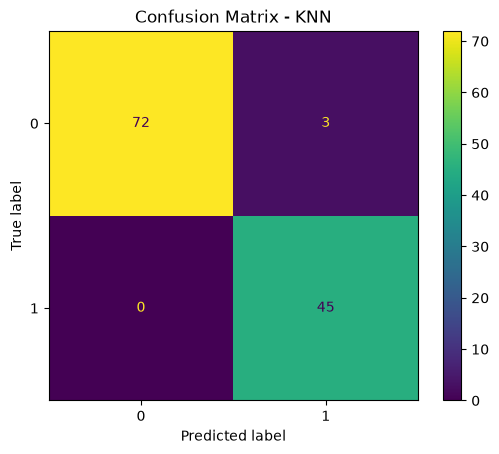

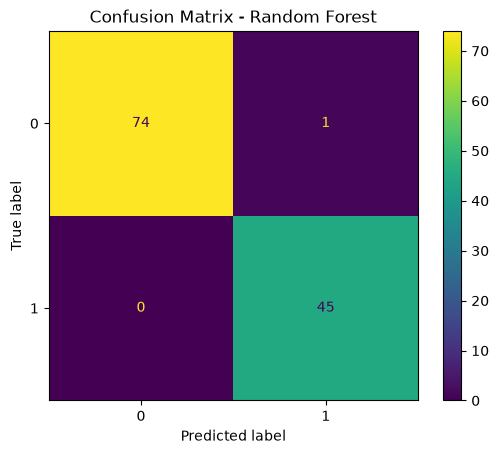

In [361]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models_pred = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "KNN": knn_pred,
    "Random Forest": rf_pred
}

for name, pred in models_pred.items():

    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot()

    plt.title(f"Confusion Matrix - {name}")

    plt.show()

In [362]:
print("Random Forest Metrics\n")

print("Precision :", precision_score(y_test, rf_pred))

print("Recall :", recall_score(y_test, rf_pred))

print("F1 Score :", f1_score(y_test, rf_pred))

Random Forest Metrics

Precision : 0.9782608695652174
Recall : 1.0
F1 Score : 0.989010989010989


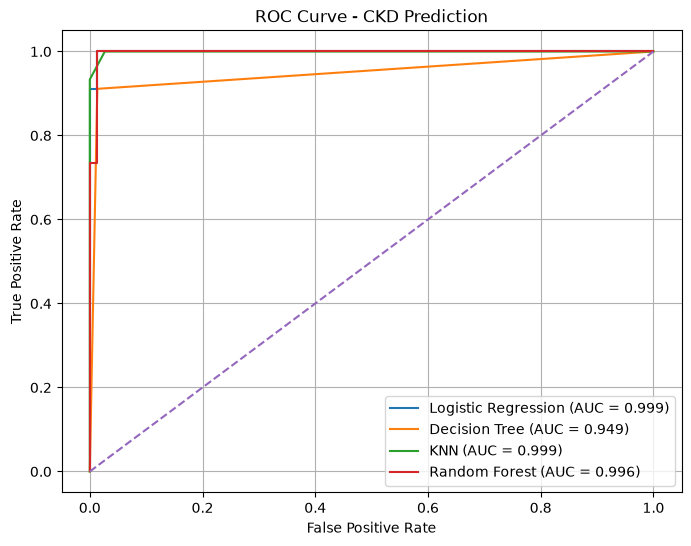

In [363]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "KNN": knn_model,
    "Random Forest": rf_model
}

plt.figure(figsize=(8, 6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - CKD Prediction")

plt.legend()
plt.grid()

plt.show()

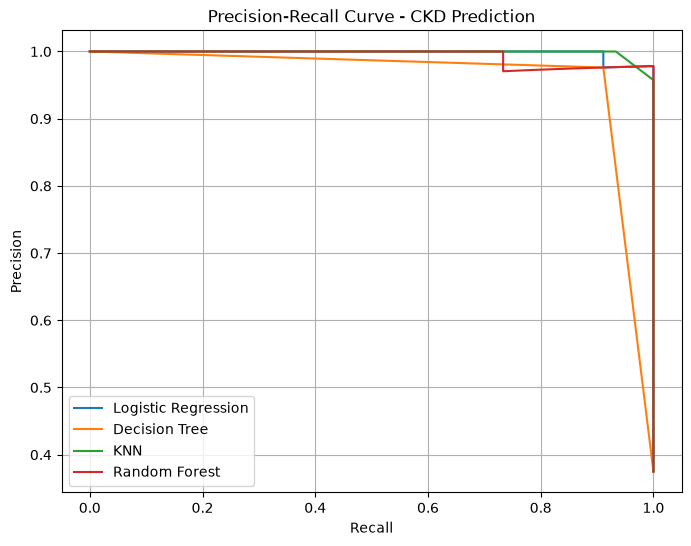

In [364]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve - CKD Prediction")

plt.legend()
plt.grid()

plt.show()

In [365]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "KNN": knn_model,
    "Random Forest": rf_model
}

cv_results = {}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_pca,
        y,
        cv=5,
        scoring="accuracy"
    )

    cv_results[name] = scores.mean()

    print("=" * 50)
    print(name)
    print("CV Scores:", scores)
    print("Average Accuracy:", scores.mean())

Logistic Regression
CV Scores: [1.     1.     0.9625 1.     1.    ]
Average Accuracy: 0.9925
Decision Tree
CV Scores: [0.9875 0.9875 0.9875 0.9875 0.9875]
Average Accuracy: 0.9875
KNN
CV Scores: [1.     0.9875 0.9625 0.9875 0.95  ]
Average Accuracy: 0.9775
Random Forest
CV Scores: [1.     1.     0.9875 1.     0.9875]
Average Accuracy: 0.9949999999999999


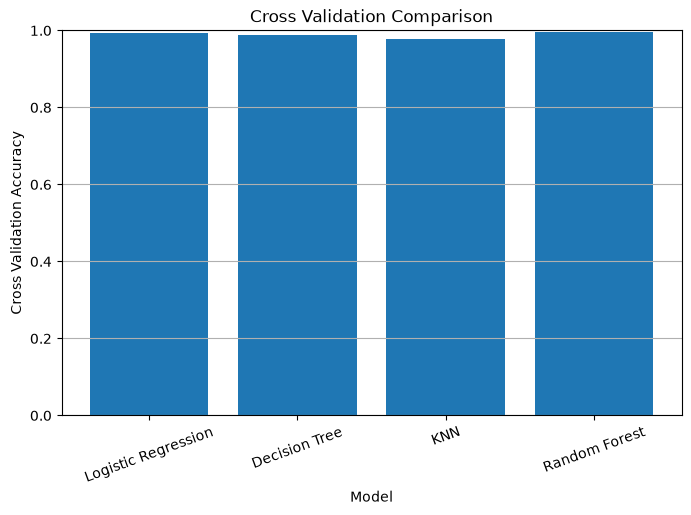

In [366]:
plt.figure(figsize=(8, 5))

plt.bar(
    cv_results.keys(),
    cv_results.values()
)

plt.xlabel("Model")
plt.ylabel("Cross Validation Accuracy")

plt.title("Cross Validation Comparison")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.grid(axis="y")

plt.show()

In [367]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "KNN",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,knn_pred),
        accuracy_score(y_test,rf_pred)
    ],

    "Precision":[
        precision_score(y_test,lr_pred),
        precision_score(y_test,dt_pred),
        precision_score(y_test,knn_pred),
        precision_score(y_test,rf_pred)
    ],

    "Recall":[
        recall_score(y_test,lr_pred),
        recall_score(y_test,dt_pred),
        recall_score(y_test,knn_pred),
        recall_score(y_test,rf_pred)
    ],

    "F1 Score":[
        f1_score(y_test,lr_pred),
        f1_score(y_test,dt_pred),
        f1_score(y_test,knn_pred),
        f1_score(y_test,rf_pred)
    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.991667,0.978261,1.000000,0.989011
1,Decision Tree,0.958333,0.976190,0.911111,0.942529
2,KNN,0.975000,0.937500,1.000000,0.967742
3,Random Forest,0.991667,0.978261,1.000000,0.989011


In [368]:
# Cell 51 - Sample Patient Input

age = 45
bp = 80
sg = 1.020
al = 1
su = 0
rbc = 1
pc = 1
pcc = 0
ba = 0
bgr = 121
bu = 36
sc = 1.2
sod = 138
pot = 4.5
hemo = 15.2
pcv = 44
wc = 7800
rc = 5.2
htn = 1
dm = 0
cad = 0
appet = 1
pe = 0
ane = 0

print("Patient details entered successfully.")

Patient details entered successfully.


In [369]:
patient = pd.DataFrame([[
    age,bp,sg,al,su,rbc,pc,pcc,ba,
    bgr,bu,sc,sod,pot,hemo,
    pcv,wc,rc,htn,dm,cad,
    appet,pe,ane
]], columns=X.columns)

patient 

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
0,45,80,1.02,1,0,1,1,0,0,121,...,15.2,44,7800,5.2,1,0,0,1,0,0


In [370]:
# Scale the patient data

patient_scaled = scaler.transform(patient)

In [371]:
# Apply PCA transformation

patient_pca = pca.transform(patient_scaled)

In [372]:
# Predict CKD

prediction = rf_model.predict(patient_pca)

probability = rf_model.predict_proba(patient_pca)

In [373]:
# Predict CKD

prediction = rf_model.predict(patient_pca)

probability = rf_model.predict_proba(patient_pca)

In [374]:
# Display Prediction

if prediction[0] == 1:
    print("Prediction : Chronic Kidney Disease (CKD) Detected")
else:
    print("Prediction : No Chronic Kidney Disease (CKD)")

Prediction : Chronic Kidney Disease (CKD) Detected


In [375]:
# Display Risk Probability

risk = probability[0][1] * 100

print("Risk Probability : {:.2f}%".format(risk))

Risk Probability : 53.00%


In [376]:
# Risk Level

if risk < 30:
    level = "LOW"

elif risk < 60:
    level = "MODERATE"

else:
    level = "HIGH"

print("Risk Level :", level)

Risk Level : MODERATE


In [377]:
# Health Recommendation

print("\nHealth Recommendation")

if prediction[0] == 1:

    print("• Consult a Nephrologist immediately")
    print("• Monitor Blood Pressure regularly")
    print("• Maintain Blood Sugar level")
    print("• Follow Kidney-Friendly Diet")
    print("• Drink sufficient water")
    print("• Perform Kidney Function Test periodically")

else:

    print("• Kidney condition appears normal")
    print("• Maintain a healthy lifestyle")
    print("• Exercise regularly")
    print("• Stay hydrated")
    print("• Have regular health checkups")


Health Recommendation
• Consult a Nephrologist immediately
• Monitor Blood Pressure regularly
• Maintain Blood Sugar level
• Follow Kidney-Friendly Diet
• Drink sufficient water
• Perform Kidney Function Test periodically


In [378]:
# Final Patient Report

print("\n========================================")
print("     EARLY CKD PREDICTION REPORT")
print("========================================")

print("Prediction      :", "CKD" if prediction[0] == 1 else "No CKD")
print("Risk Percentage :", "{:.2f}%".format(risk))
print("Risk Level      :", level)

print("========================================")
print("Prediction Completed Successfully")
print("========================================")


     EARLY CKD PREDICTION REPORT
Prediction      : CKD
Risk Percentage : 53.00%
Risk Level      : MODERATE
Prediction Completed Successfully
